In [1]:
from langchain_ollama import ChatOllama

model = ChatOllama(model="gpt-oss:120b-cloud")
print('Model is ready')


c:\Users\ak60492\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Model is ready


In [3]:
#response = model.invoke("WHich is the capital city of India?")
response = model.invoke("How is the weather today in Pune?")
print(response)

content='I’m not able to pull live weather data, so I can’t tell you the exact conditions in Pune right this minute.  \n\n**What you can do to get the current weather:**\n\n| Platform | How to check |\n|----------|--------------|\n| **Google** | Search “Pune weather” – a quick snapshot appears at the top of the results. |\n| **Weather.com** | Go to <https://weather.com/weather/today/l/Pune+India> for a detailed overview. |\n| **AccuWeather** | <https://www.accuweather.com/en/in/pune/204131/weather-forecast/204131> |\n| **India Meteorological Department (IMD)** | <https://mausam.imd.gov.in/> (official government source). |\n| **Mobile apps** | • **Weather** (iOS)  • **Google Weather** (Android)  • **Mausam** (IMD’s official app) |\n| **Voice assistants** | Ask “Hey Siri / Google, what’s the weather in Pune?” |\n\n---\n\n### Typical September Weather in Pune\n\n| Parameter | Typical Range |\n|-----------|---------------|\n| **Temperature** | 21\u202f°C\u202f–\u202f30\u202f°C (70\u202f°F\

In [9]:
from langchain_community.tools import tool

@tool
def get_weather(city: str) -> str:
    """Get weather for a city"""
    return f"The weather in the city {city} is Sunny"

@tool
def get_stock_price(stock: str) -> str:
    """Returns the stock price for a given stock"""
    return f"The stock price of {stock} is 25.50"

get_weather
get_stock_price

StructuredTool(name='get_stock_price', description='Returns the stock price for a given stock', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001A3DA5363E0>)

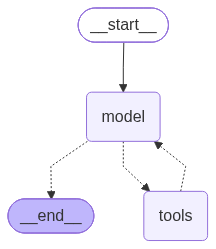

In [10]:
from langchain.agents import create_agent

ALL_TOOLS = [get_weather, get_stock_price]

agent = create_agent(
    model=model,
    tools=ALL_TOOLS,
    system_prompt="You are a helpful assistant. You can provide the weather information with the help of get_weather tool"
)

agent

In [11]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "Which is the capital city of India?"}
    ]
})

response

{'messages': [HumanMessage(content='Which is the capital city of India?', additional_kwargs={}, response_metadata={}, id='a8142a00-8e79-4b43-95c3-b2ad7d613184'),
  AIMessage(content='The capital city of India is **New\u202fDelhi**.', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-15T04:35:22.882666494Z', 'done': True, 'done_reason': 'stop', 'total_duration': 307294272, 'load_duration': None, 'prompt_eval_count': 177, 'prompt_eval_duration': None, 'eval_count': 49, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0a359-1fc1-7183-aedd-2251fa51c56a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 177, 'output_tokens': 49, 'total_tokens': 226})]}

In [12]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "How is the weather in Pune today?"}
    ]
})

response

{'messages': [HumanMessage(content='How is the weather in Pune today?', additional_kwargs={}, response_metadata={}, id='46bbd50b-020b-4946-9439-e40450b14c42'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-15T04:35:33.292684642Z', 'done': True, 'done_reason': 'stop', 'total_duration': 331229941, 'load_duration': None, 'prompt_eval_count': 177, 'prompt_eval_duration': None, 'eval_count': 53, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0a359-4946-73c2-b8ab-725fc597b9ee-0', tool_calls=[{'name': 'get_weather', 'args': {'city': 'Pune'}, 'id': '0dd5a589-7d12-49fa-82ee-f1f58eb69e53', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 177, 'output_tokens': 53, 'total_tokens': 230}),
  ToolMessage(content='The weather in the city Pune is Sunny', name='get_weather', id='226b1257-166c-4388-b1ee-4699bccf205e', tool_call_id='0dd5a589-7d

In [13]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the stock price of Zensar?"}
    ]
})

response

{'messages': [HumanMessage(content='What is the stock price of Zensar?', additional_kwargs={}, response_metadata={}, id='b41297f3-2a12-408e-9d9e-04e0c9f49ef1'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-15T04:36:20.501036702Z', 'done': True, 'done_reason': 'stop', 'total_duration': 543705816, 'load_duration': None, 'prompt_eval_count': 179, 'prompt_eval_duration': None, 'eval_count': 52, 'eval_duration': None, 'logprobs': None, 'model_name': 'gpt-oss:120b', 'model_provider': 'ollama'}, id='lc_run--01a0a35a-00d6-79f2-a1c5-d26d12029c8a-0', tool_calls=[{'name': 'get_stock_price', 'args': {'stock': 'Zensar'}, 'id': '3d9f5bad-b0c2-4a93-ab9a-e4fec59f7c8a', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 179, 'output_tokens': 52, 'total_tokens': 231}),
  ToolMessage(content='The stock price of Zensar is 25.50', name='get_stock_price', id='17cca97f-4e31-4f17-ba6c-5c7287d680c3', tool_call_id='3d

In [14]:
response = agent.invoke({
    "messages": [
        {"role": "user", "content": "What is the breaking news today in India?"}
    ]
})

response

{'messages': [HumanMessage(content='What is the breaking news today in India?', additional_kwargs={}, response_metadata={}, id='a1eee15e-5b2c-4a59-afef-e641ffe6fe55'),
  AIMessage(content='I’m sorry—I don’t have real‑time access to news feeds, so I can’t provide today’s breaking stories from India. For the most up‑to‑date coverage, you might check reputable sources such as\u202fthe\u202fTimes of India,\u202fThe Hindu,\u202fNDTV,\u202fIndia Today, or international outlets with India sections like the BBC, Reuters, or Al\u202fJazeera. Their websites, mobile apps, or social‑media channels usually highlight the latest headlines as they develop. If you have a specific topic or region in mind, let me know and I can give you background information or explain related context!', additional_kwargs={}, response_metadata={'model': 'gpt-oss:120b', 'created_at': '2026-09-15T04:38:26.806514242Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1254862422, 'load_duration': None, 'prompt_eval_co